In [2]:
import numpy as np
import pandas as pd

#plots
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Machine Learning
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

# statsmodels
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
df = pd.read_excel("/content/Raisin_Dataset.xlsx")

In [4]:
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


## Stats

*   There are no null values observed.
*   One categorical feature



In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             900 non-null    int64  
 1   MajorAxisLength  900 non-null    float64
 2   MinorAxisLength  900 non-null    float64
 3   Eccentricity     900 non-null    float64
 4   ConvexArea       900 non-null    int64  
 5   Extent           900 non-null    float64
 6   Perimeter        900 non-null    float64
 7   Class            900 non-null    object 
dtypes: float64(5), int64(2), object(1)
memory usage: 56.4+ KB


In [6]:
df.shape

(900, 8)

In [7]:
df["Class"].value_counts()

,count
Class,
Kecimen,450
Besni,450


Target feature is perfectly balanced

In [8]:
# Descriptive stats for numerical features
df1 = df.iloc[:,0:7]
df1.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000


## Box plots

We can see in the box plot of Area
1. Median line is closer to Q1 than to Q3
2. Right half of the box is longer and right whisker is long too implying right skewness
3. There are dots that depicts outliers.

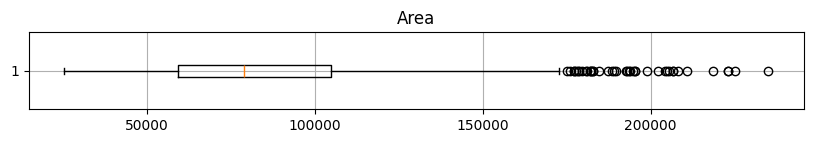

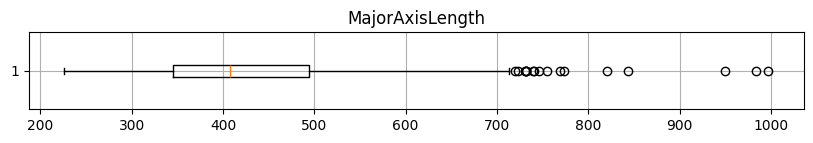

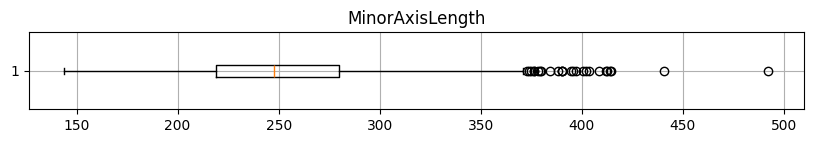

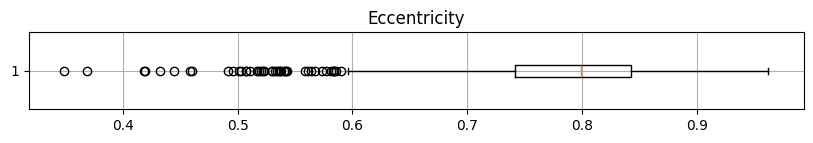

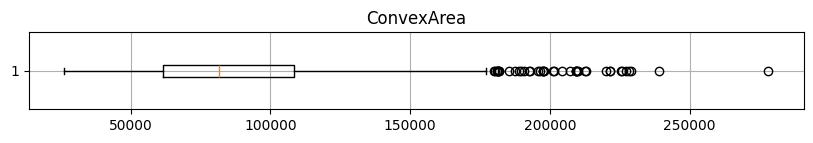

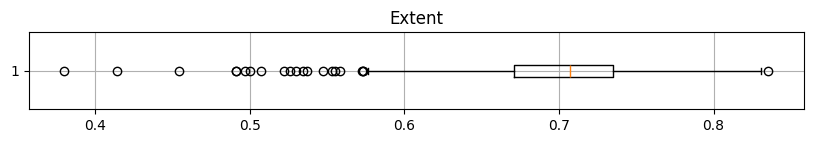

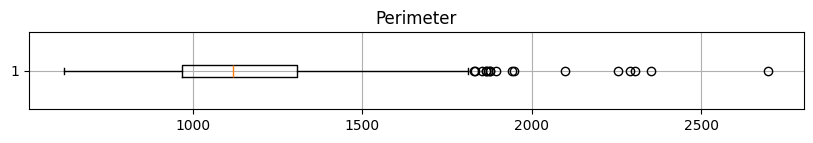

In [9]:
for f in df1:
  plt.figure(figsize=(10,1))
  plt.boxplot(x=df[f], vert=False)
  plt.title(f)
  plt.grid()
  plt.show()

## Feature Correlations

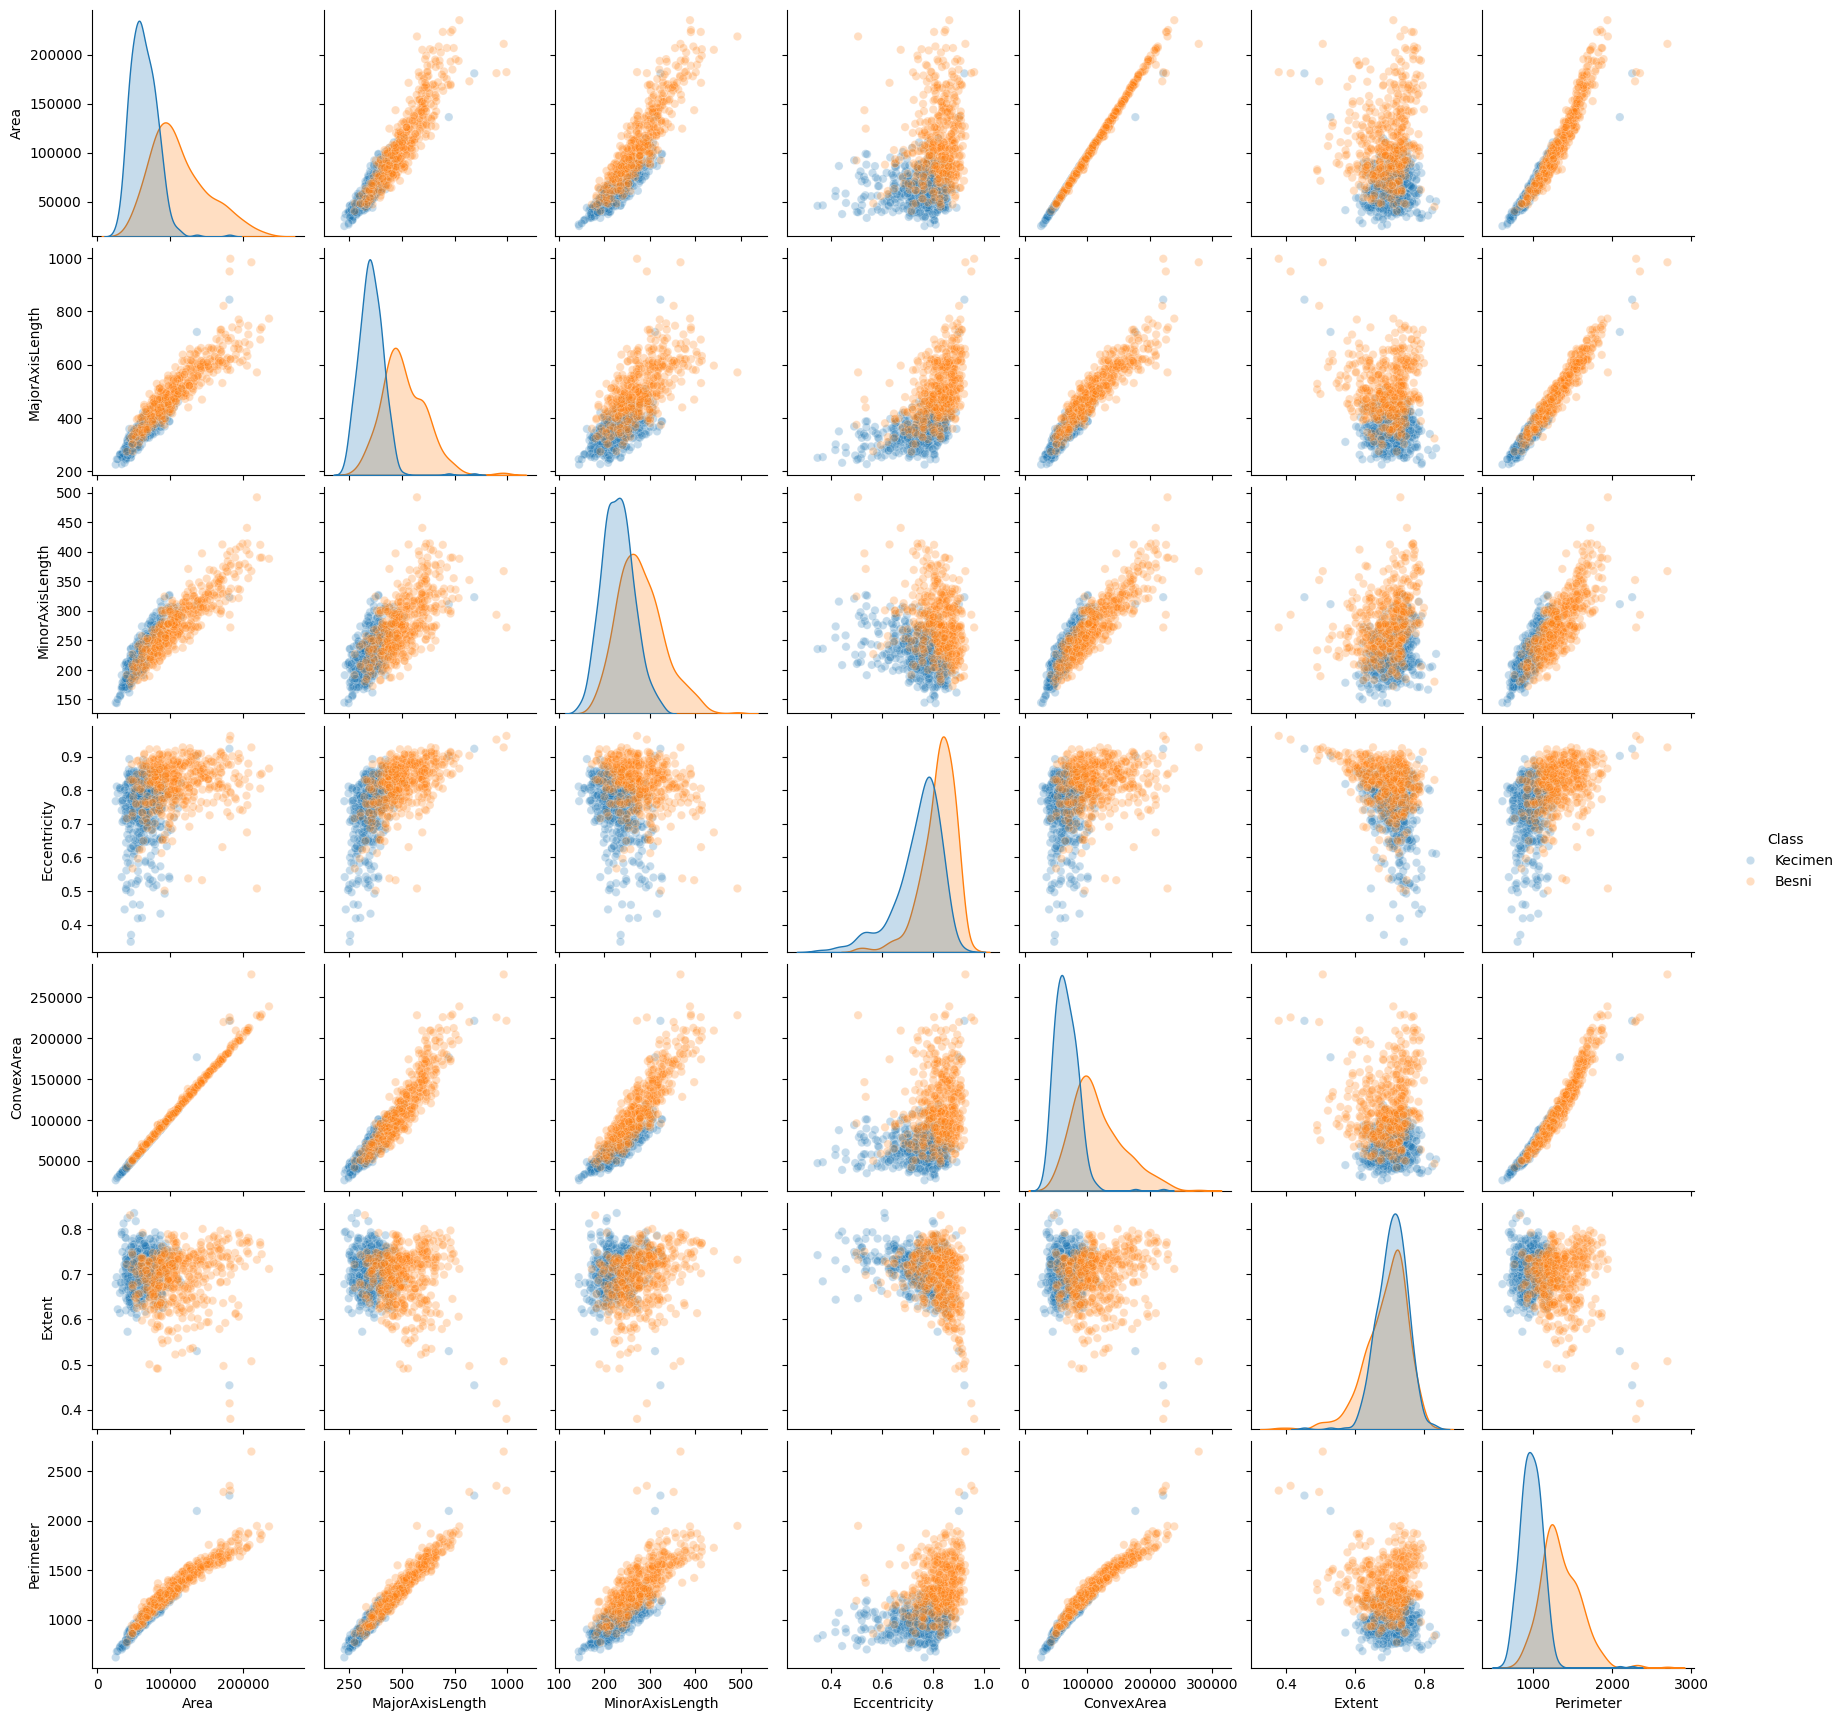

In [10]:
# pairwise scatterplot, representing Class by color
sns.pairplot(df, hue='Class',
             plot_kws = {'alpha' : 0.25})
plt.show()

This is what we observed from the box plot too. The plot is right skewed and we can see presence of outliers from the extended right tail. (Probab of the occurence of these pts is low)

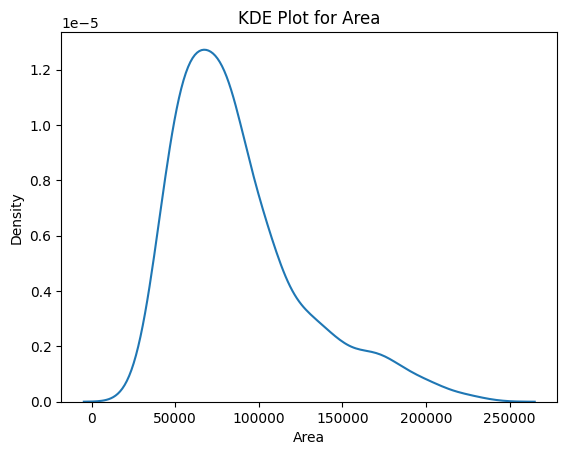

In [11]:
sns.kdeplot(df['Area'])
plt.title('KDE Plot for Area')
plt.show()

## Feature correlations

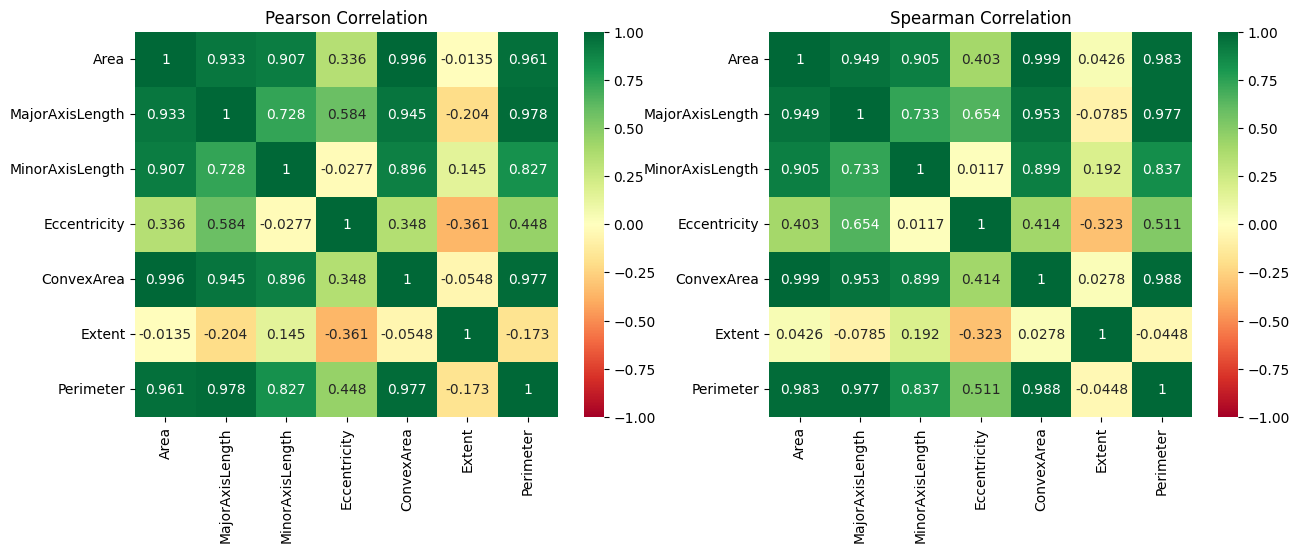

In [12]:
# finding correlation of the numerical features and making heatmaps
corr_pearson = df1.corr(method="pearson")
corr_spearman = df1.corr(method="spearman")

plt.figure(figsize=(15,5))
ax1 = plt.subplot(1,2,1)
sns.heatmap(corr_pearson, annot=True, cmap='RdYlGn',
            fmt='.3g', vmin=-1, vmax=+1)
plt.title('Pearson Correlation')

ax2 = plt.subplot(1,2,2, sharex=ax1)
sns.heatmap(corr_spearman, annot=True, cmap='RdYlGn',
            fmt='.3g', vmin=-1, vmax=+1)
plt.title('Spearman Correlation')
plt.show()

## Correlation Matrix and Multicollinearity check

Determinant of the matrix is non zero which implies the features are not dependent on each other.

In [13]:
det_A = np.linalg.det(corr_pearson)
print(det_A)

3.5535828943333195e-08


## Feature Distributions by Class

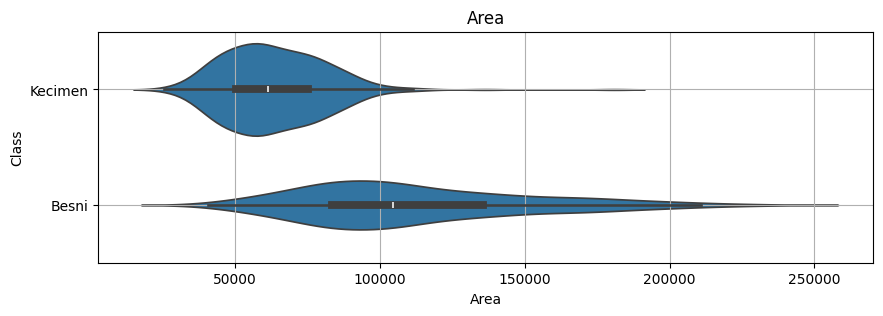

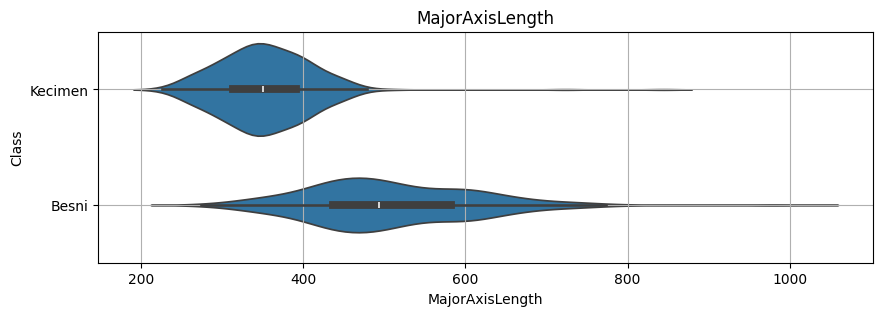

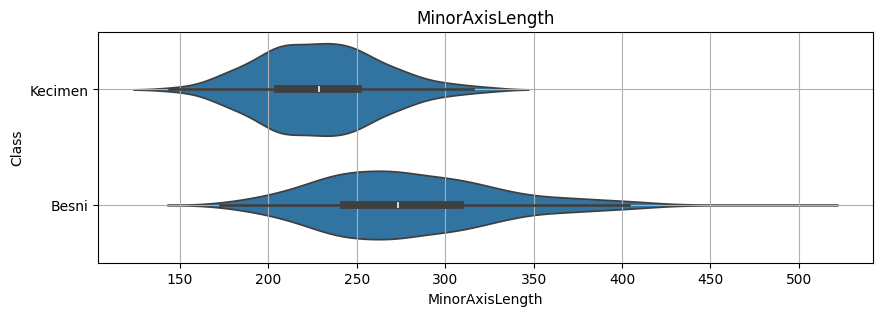

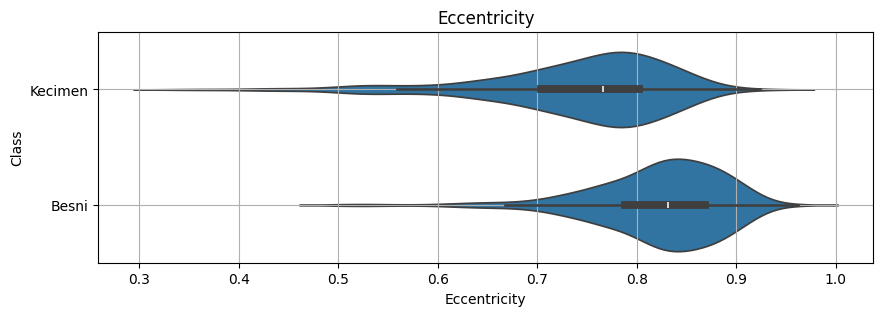

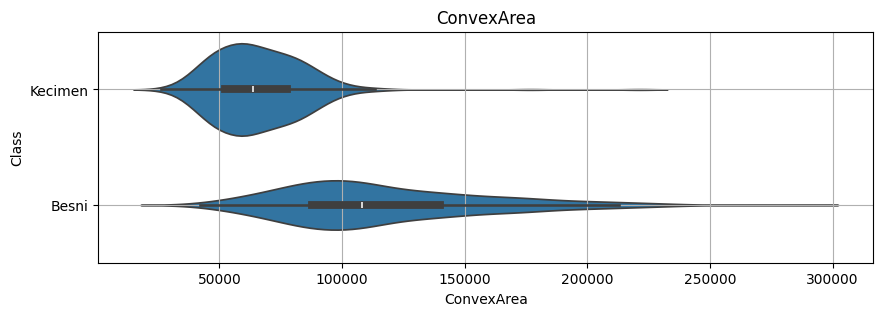

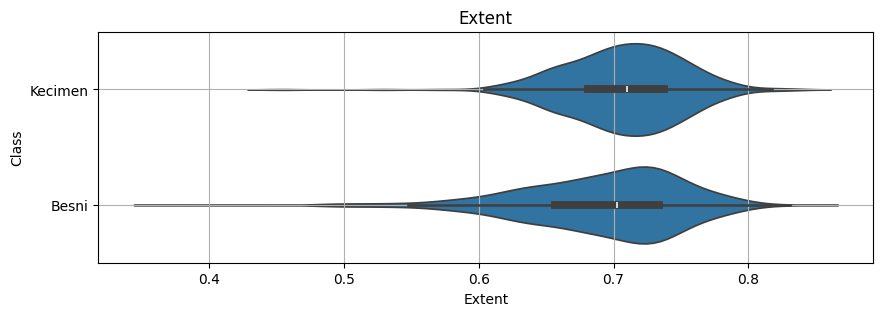

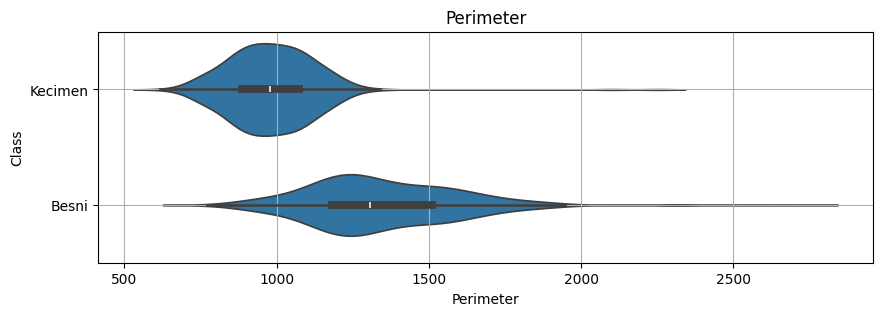

In [14]:
# plot distributions split by class for each feature
for f in df1:
    plt.figure(figsize=(10,3))
    sns.violinplot(data=df, y='Class', x=f)
    plt.grid()
    plt.title(f)
    plt.show()

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Prepare the data for VIF calculation (numerical features)
X = df1 # df1 contains the numerical features

# Add a constant term for the intercept, which is required for VIF calculation
X = sm.add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("Variance Inflation Factor (VIF) for numerical features:")
print(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) for numerical features:
           feature          VIF
0            const  1125.800042
5       ConvexArea   445.947568
1             Area   404.718824
7        Perimeter   184.252844
2  MajorAxisLength   129.152882
3  MinorAxisLength    40.166637
4     Eccentricity     5.210356
6           Extent     1.605335


VIF > 10 indicates serious multicollinearity

In [16]:
y = df['Class'].map({'Kecimen': 0, 'Besni': 1})
X = df1.drop(['ConvexArea', 'Perimeter', 'Area', 'MajorAxisLength'], axis=1) # Drop features with high VIF

# Add a constant to the independent variables
X = sm.add_constant(X)

# Fit the logistic regression model
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# Print the model summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.368208
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  Class   No. Observations:                  900
Model:                          Logit   Df Residuals:                      896
Method:                           MLE   Df Model:                            3
Date:                Tue, 26 May 2026   Pseudo R-squ.:                  0.4688
Time:                        18:11:57   Log-Likelihood:                -331.39
converged:                       True   LL-Null:                       -623.83
Covariance Type:            nonrobust   LLR p-value:                1.900e-126
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -24.1001      2.672     -9.019      0.000     -29.337     -18.863
MinorAxisLengt

## Dimensionality Reduction - PCA

In [17]:
# standardize features
df4pca_std = StandardScaler().fit_transform(df1)
# run PCA
pc_model = PCA(n_components=3)
pc = pc_model.fit_transform(df4pca_std)
# append PCA components to original data frame
df['pc_1'] = pc[:,0]
df['pc_2'] = pc[:,1]
df['pc_3'] = pc[:,2]

In [18]:
# interactive 3D plot - colored by class; size ~ area
fig = px.scatter_3d(df, x='pc_1', y='pc_2', z='pc_3',
                    color=df.Class.astype(str),
                    size=df.Area,
                    hover_data=df1,
                    opacity=0.35)
fig.update_layout(title='Visualization using PCA dimension reduction')
fig.show()

### Explained Variance Ratio

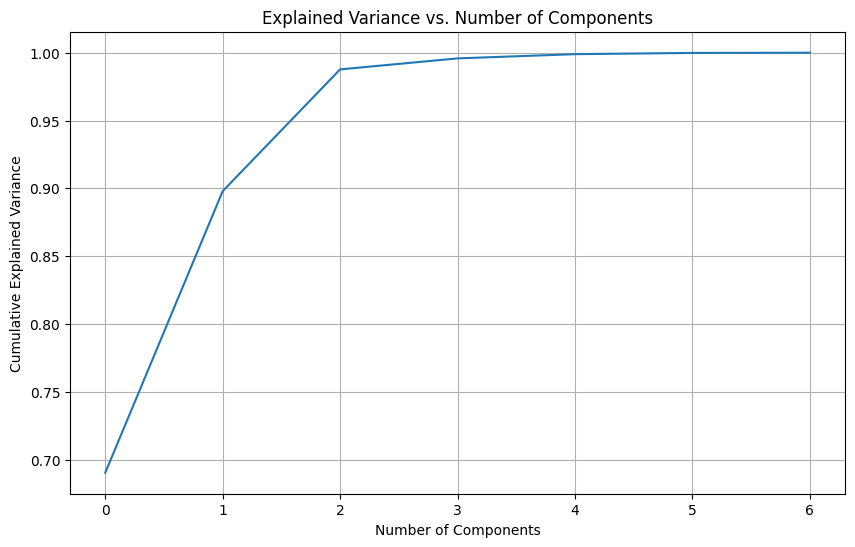

In [19]:
# Re-run PCA without limiting the number of components to analyze explained variance
pca_full = PCA()
pca_full.fit(df4pca_std)

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

From this plot, you can observe how much of the total variance is explained as you increase the number of principal components. A common practice is to choose the number of components where the curve starts to flatten out, indicating diminishing returns in terms of explained variance. In the previous code, 3 components were selected as an initial reasonable choice to capture a significant portion of the variance while reducing dimensionality for visualization purposes. However, based on this plot, you can decide if a different number of components would be more appropriate for your specific needs.

So here it started flattening out at 3.

## Logistic Regression

In [21]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(df1, df['Class'],
                                                    test_size=0.3, random_state=1234)

In [23]:
scaler = StandardScaler()

In [24]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegression
logistic_regression_model = LogisticRegression()
logistic_regression_model.fit(X_train_scaled, y_train)

LogisticRegression()

In [26]:
logistic_regression_model.coef_

array([[-0.06702068, -0.60027392,  0.54475596, -0.16003451, -0.40746049,
         0.29622907, -2.55905905]])

In [27]:
logistic_regression_model.intercept_

array([-0.71626358])

In [28]:
y_pred = logistic_regression_model.predict(X_test_scaled)
y_pred

array(['Kecimen', 'Besni', 'Kecimen', 'Besni', 'Besni', 'Kecimen',
       'Besni', 'Besni', 'Kecimen', 'Besni', 'Besni', 'Kecimen', 'Besni',
       'Besni', 'Besni', 'Kecimen', 'Besni', 'Kecimen', 'Kecimen',
       'Kecimen', 'Besni', 'Kecimen', 'Besni', 'Kecimen', 'Besni',
       'Kecimen', 'Kecimen', 'Besni', 'Kecimen', 'Kecimen', 'Besni',
       'Besni', 'Kecimen', 'Besni', 'Kecimen', 'Kecimen', 'Kecimen',
       'Kecimen', 'Besni', 'Kecimen', 'Besni', 'Kecimen', 'Besni',
       'Besni', 'Besni', 'Besni', 'Kecimen', 'Kecimen', 'Besni',
       'Kecimen', 'Kecimen', 'Kecimen', 'Kecimen', 'Besni', 'Besni',
       'Besni', 'Kecimen', 'Kecimen', 'Kecimen', 'Kecimen', 'Kecimen',
       'Besni', 'Kecimen', 'Besni', 'Besni', 'Kecimen', 'Kecimen',
       'Besni', 'Besni', 'Kecimen', 'Kecimen', 'Kecimen', 'Besni',
       'Kecimen', 'Besni', 'Kecimen', 'Kecimen', 'Besni', 'Besni',
       'Besni', 'Kecimen', 'Besni', 'Kecimen', 'Besni', 'Kecimen',
       'Besni', 'Kecimen', 'Besni', 'Besni', 'K

In [29]:
score = logistic_regression_model.score(X_test_scaled, y_test)
score

0.8740740740740741

Logistic Regression Evaluation Metrics:

Classification Report:
              precision    recall  f1-score   support

       Besni       0.81      0.92      0.87       118
     Kecimen       0.93      0.84      0.88       152

    accuracy                           0.87       270
   macro avg       0.87      0.88      0.87       270
weighted avg       0.88      0.87      0.87       270





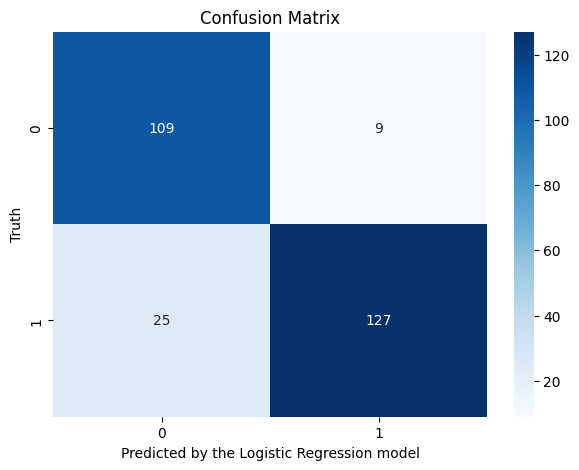

In [31]:
from sklearn.metrics import confusion_matrix, classification_report
y_pred = logistic_regression_model.predict(X_test_scaled)

# Calculate confusion matrix and classification report
cm = confusion_matrix(y_test, y_pred)
classif_report = classification_report(y_test, y_pred)

model_evaluation_metrics = {}
model_evaluation_metrics['Logistic Regression'] = {
    "Confusion Matrix": cm,
    'Classification Report': classif_report
}

print(f"Logistic Regression Evaluation Metrics:")
print("\nClassification Report:")
print(classif_report)
print("\n" + "="*60 + "\n")

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')  # Using 'Blues' colormap
plt.xlabel('Predicted by the Logistic Regression model')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()

## Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier
# define random forest model
clf = RandomForestClassifier(n_estimators=10,
                             max_depth=8,
                             random_state = 111)

In [34]:
# cross validation scores
scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='roc_auc')
scores

array([0.91502525, 0.87916667, 0.95530303, 0.93169744, 0.92259044])

In [35]:
print('CV AUC - mean: ', np.mean(scores))
print('CV AUC - stdev:', np.std(scores))

CV AUC - mean:  0.9207565664231488
CV AUC - stdev: 0.02481568775821346


In [36]:
# fit model
clf.fit(X_train,y_train)

RandomForestClassifier(max_depth=8, n_estimators=10, random_state=111)

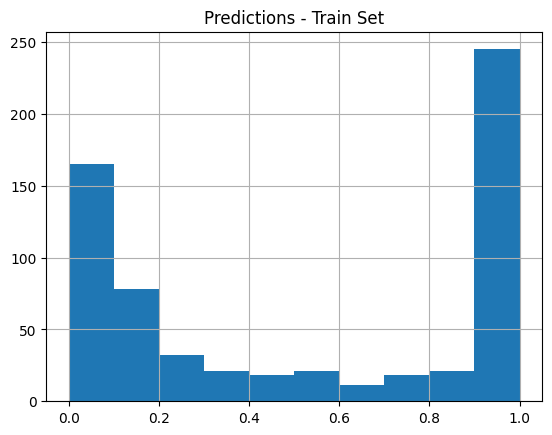

In [37]:
# predict on train set
y_train_pred = pd.DataFrame(clf.predict_proba(X_train), columns=['p0','p1'])
y_train_pred_p = y_train_pred.p0
# plot predictions (probabilities)
plt.hist(y_train_pred_p)
plt.title('Predictions - Train Set')
plt.grid()
plt.show()

In [38]:
# convert target to 0/1
y_train_01 = pd.factorize(y_train)
y_train_01 = y_train_01[0]

In [39]:
# ROC Curve and AUC
fpr, tpr, threshold = metrics.roc_curve(y_train_01, y_train_pred_p)
auc_train = metrics.auc(fpr,tpr)
print('AUC Train:', auc_train)

AUC Train: 0.9950169806743754


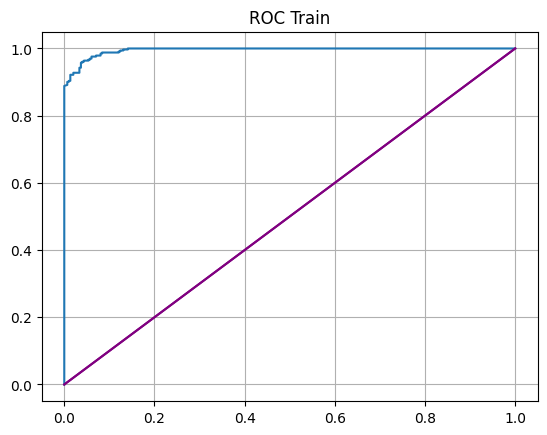

In [40]:
# plot ROC Curve
plt.plot(fpr, tpr)
plt.plot([(0,0),(1,1)], c='purple')
plt.title('ROC Train')
plt.grid()
plt.show()

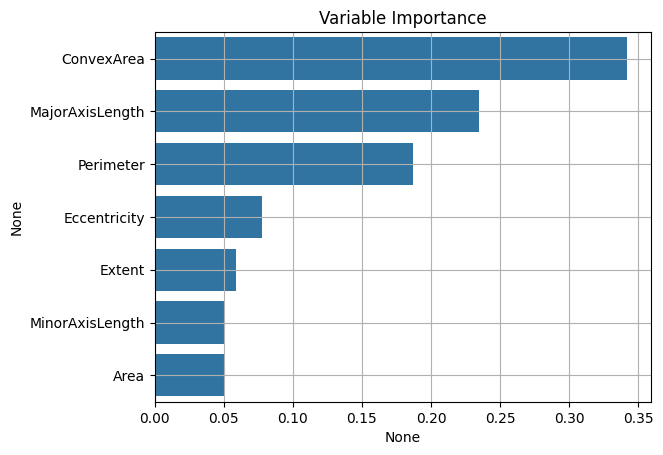

In [41]:
# get variable importance
feature_imp = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
# plot variable importance
sns.barplot(x=feature_imp, y=feature_imp.index)
plt.title('Variable Importance')
plt.grid()
plt.show()

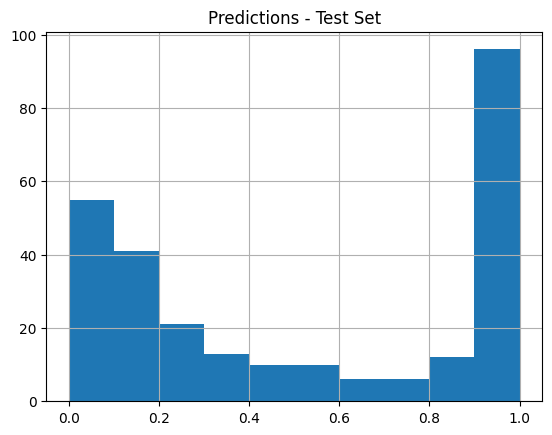

In [42]:
# predict on test set
y_test_pred = pd.DataFrame(clf.predict_proba(X_test), columns=['p0','p1'])
y_test_pred_p = y_test_pred.p0

# plot predictions (probabilities)
plt.hist(y_test_pred_p)
plt.title('Predictions - Test Set')
plt.grid()
plt.show()

In [43]:
# convert target to 0/1
y_test_01 = pd.factorize(y_test)
y_test_01 = y_test_01[0]

In [44]:
# ROC Curve and AUC
fpr, tpr, threshold = metrics.roc_curve(y_test_01, y_test_pred_p)
auc_test = metrics.auc(fpr,tpr)
print('AUC Test:', auc_test)

AUC Test: 0.9412355040142729


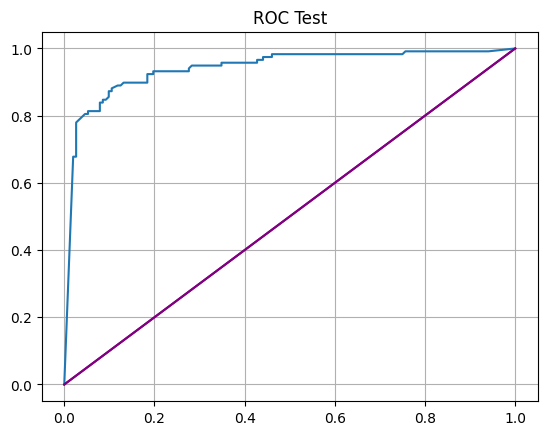

In [45]:
# plot ROC Curve
plt.plot(fpr, tpr)
plt.plot([(0,0),(1,1)], c='purple')
plt.title('ROC Test')
plt.grid()
plt.show()